In [5]:
import pandas as pd
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Feature - 1 (Family Size)

In [6]:
# Create family size
df['FamilySize'] = df['SibSp'] + df['Parch']
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


# Feature-2 (Title Extraction)

In [9]:
df['Title'] = df['Name'].str.extract(r'([A-Za-z]+)\.', expand = False)

# Feature-3 : Age Group

In [10]:
# Create Age Group
bins = [0,12,18,35,60,100]
labels = ['Child','Teens','Adult','Middle Age','Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Feature-4 (is_alone)

In [11]:
df['IsAlone'] = (df['FamilySize']==1).astype(int)

In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Title,AgeGroup,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,Mr,Adult,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,Mrs,Middle Age,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,Miss,Adult,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,Mrs,Adult,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,Mr,Adult,0


In [13]:
# Here We created 4 New Features(FamilySize,Title,AgeGroup,IsAlone)

# Visualization

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


# Plot -1 Survival by Gender

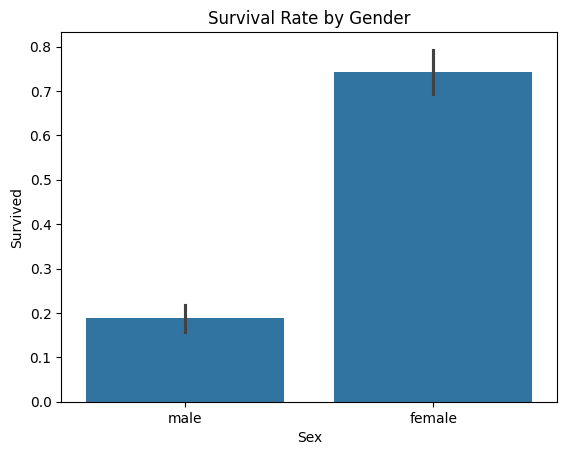

In [15]:
sns.barplot(x='Sex',y = 'Survived', data = df)
plt.title('Survival Rate by Gender')
plt.show()

# Plot-2 Survival by Class

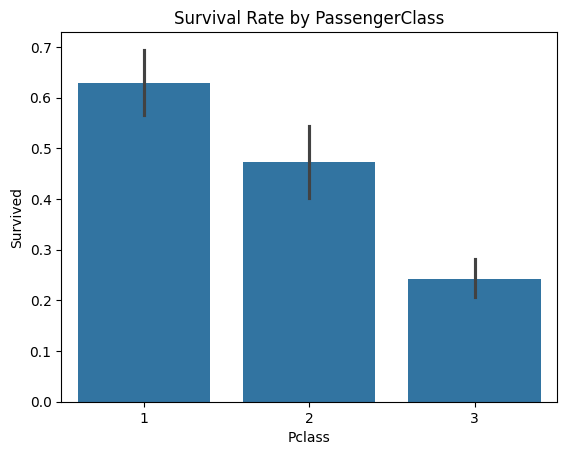

In [16]:
sns.barplot(x='Pclass',y = 'Survived', data = df)
plt.title('Survival Rate by PassengerClass')
plt.show()

# Plot - 3 Survival by Age Group

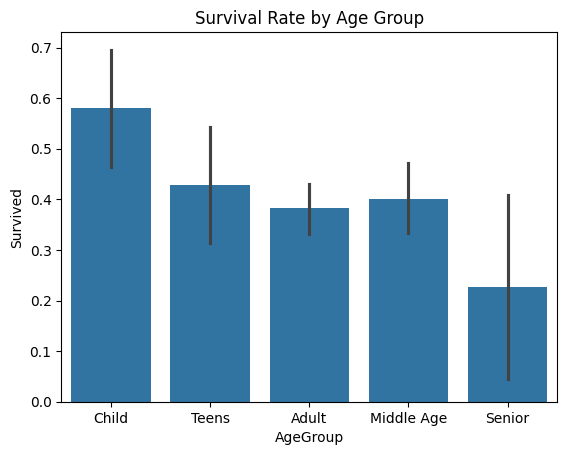

In [17]:
sns.barplot(x='AgeGroup',y = 'Survived', data = df)
plt.title('Survival Rate by Age Group')
plt.show()

# Heatmap (Correlation)

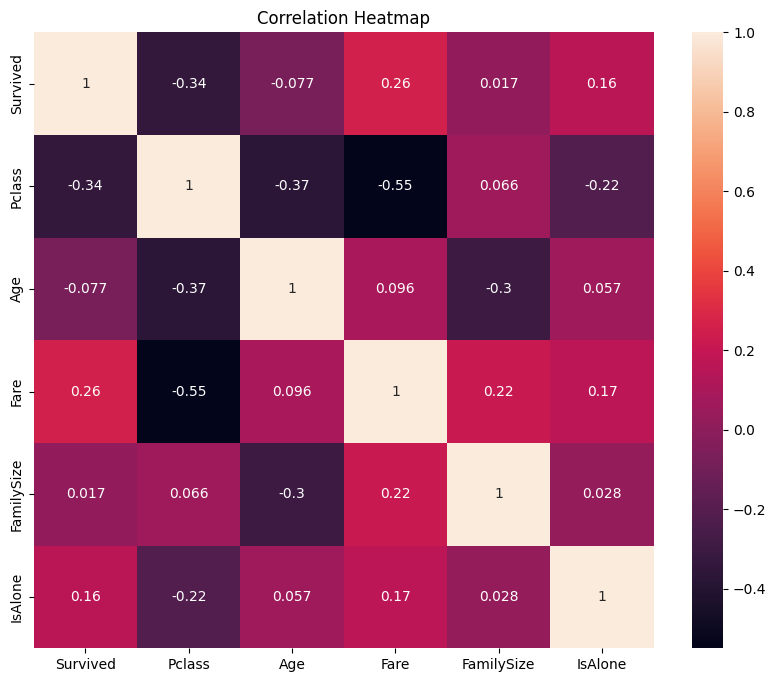

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df[['Survived','Pclass','Age','Fare','FamilySize','IsAlone']].corr(),annot  = True)
plt.title('Correlation Heatmap')
plt.show()
            